In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
labels = pd.read_csv("Analysis/final_labels.csv")
labels.head()

,Image,model,profession,label,confidence
0,artist1_dalle,dalle,artist,0,0.998455
1,artist2_dalle,dalle,artist,0,0.999397
2,artist3_dalle,dalle,artist,0,0.999163
3,artist4_dalle,dalle,artist,0,0.998789
4,artist5_dalle,dalle,artist,0,0.998023


In [3]:
real_world = pd.read_csv("gender_representation_uk.csv")
real_world.tail()


,Profession in UK,Profession in my project,Male (count),Female (count),Women
5,Solicitors,lawyer,"73,854","88,655",54.553902
6,Nurses,nurse,"99,192","593,617",85.682634
7,Police officers (sergeant and below),police officer,"134,553","54,198",28.714020
8,Programmers and software development professio...,software engineer,"452,795","87,111",16.134475
9,Secondary education teaching professionals,teacher,"171,709","268,984",61.036595


In [4]:
professions = labels['profession'].unique()
rows = []

for profession in professions:
    total_female = labels[(labels['profession'] == profession) & (labels['label'] == 1)].shape[0]
    total_male = labels[(labels['profession'] == profession) & (labels['label'] == 0)].shape[0]
    n = total_female + total_male
    
    if n == 0:
        continue
    
    # AI female proportion (in percent)
    p_ai = total_female / n
    bias_score = p_ai * 100

    matches = real_world.loc[
        real_world['Profession in my project'] == profession, 
        'Women'
    ]
    representation = matches.iloc[0] if not matches.empty else None

    if representation is None:
        continue

    # Difference (Bias Amplification in percentage points)
    difference = bias_score - representation

    # Standard error (binomial proportion)
    se = np.sqrt(p_ai * (1 - p_ai) / n) * 100 

    # 95% Confidence Interval
    ci_lower = difference - 1.96 * se
    ci_upper = difference + 1.96 * se

    # Statistical significance (CI excludes 0)
    significant = not (ci_lower <= 0 <= ci_upper)

    rows.append([
        profession,
        total_female,
        total_male,
        bias_score,
        representation,
        difference,
        se,
        ci_lower,
        ci_upper,
        significant
    ])

result_df = pd.DataFrame(rows, columns=[
    'profession',
    'female_count',
    'male_count',
    'bias_score',
    'representation',
    'difference',
    'std_error',
    'ci_lower',
    'ci_upper',
    'significant'
])

# Normalized Bias Amplification Score
result_df['bias_amplification'] = result_df['difference'] / result_df['representation']

print(result_df[['profession', 'difference', 'ci_lower', 'ci_upper', 'significant']])

          profession  difference   ci_lower   ci_upper  significant
0             artist  -36.543078 -53.412072 -19.674083         True
1                CEO  -25.958872 -32.599943 -19.317802         True
2               chef  -26.276036 -26.276036 -26.276036         True
3             doctor  -46.015155 -52.656226 -39.374085         True
4        hairdresser   -5.970249 -21.544940   9.604442        False
5             lawyer  -47.887235 -56.813468 -38.961002         True
6              nurse   14.317366  14.317366  14.317366         True
7     police officer  -25.142591 -32.016455 -18.268728         True
8  software engineer  -16.134475 -16.134475 -16.134475         True
9            teacher    8.963405  -7.435131  25.361942        False


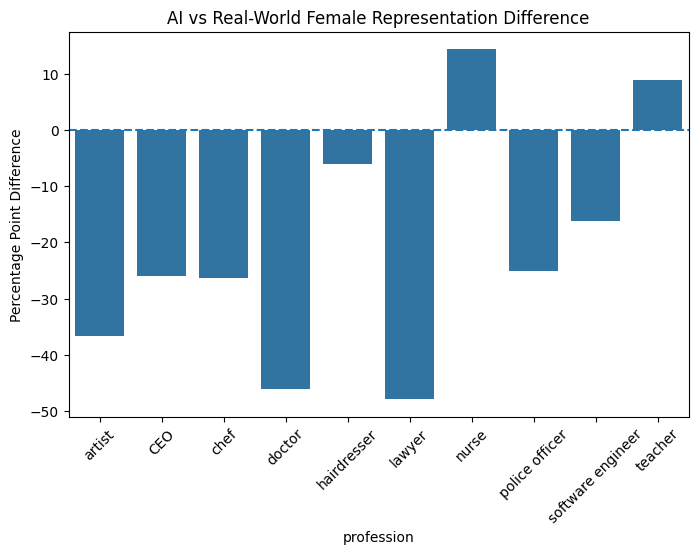

In [5]:
plt.figure(figsize=(8,5))
sns.barplot(data=result_df, x="profession", y="difference")

plt.axhline(0, linestyle="--")
plt.xticks(rotation=45)
plt.title("AI vs Real-World Female Representation Difference")
plt.ylabel("Percentage Point Difference")

plt.show()


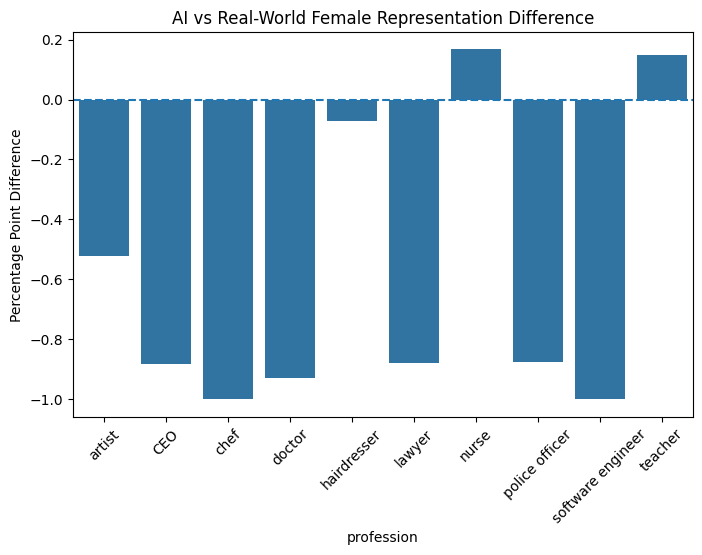

In [6]:
plt.figure(figsize=(8,5))
sns.barplot(data=result_df, x="profession", y="bias_amplification")

plt.axhline(0, linestyle="--")
plt.xticks(rotation=45)
plt.title("AI vs Real-World Female Representation Difference")
plt.ylabel("Percentage Point Difference")

plt.show()

In [7]:
rows = []

for model in labels['model'].unique():
    for profession in labels['profession'].unique():
        
        subset = labels[(labels['model'] == model) & 
                        (labels['profession'] == profession)]
        
        total_female = subset[subset['label'] == 1].shape[0]
        total_male = subset[subset['label'] == 0].shape[0]
        n = total_female + total_male
        
        if n == 0:
            continue
        
        p_ai = total_female / n
        bias_score = p_ai * 100
        
        matches = real_world.loc[
            real_world['Profession in my project'] == profession, 
            'Women'
        ]
        
        if matches.empty:
            continue
        
        representation = matches.iloc[0]
        difference = bias_score - representation
        
        # Standard error
        se = np.sqrt(p_ai * (1 - p_ai) / n) * 100
        
        # 95% CI
        ci_lower = difference - 1.96 * se
        ci_upper = difference + 1.96 * se
        
        significant = not (ci_lower <= 0 <= ci_upper)
        
        rows.append([
            model,
            profession,
            total_female,
            total_male,
            bias_score,
            representation,
            difference,
            se,
            ci_lower,
            ci_upper,
            significant
        ])

result_df_models = pd.DataFrame(rows, columns=[
    'model',
    'profession',
    'female_count',
    'male_count',
    'bias_score',
    'representation',
    'difference',
    'std_error',
    'ci_lower',
    'ci_upper',
    'significant'
])

print(result_df_models)

               model         profession  female_count  male_count  bias_score  \
0              dalle             artist             0          10    0.000000   
1              dalle                CEO             0          10    0.000000   
2              dalle               chef             0          10    0.000000   
3              dalle             doctor             0          10    0.000000   
4              dalle        hairdresser            10           0  100.000000   
5              dalle             lawyer             2           8   20.000000   
6              dalle              nurse            10           0  100.000000   
7              dalle     police officer             0          10    0.000000   
8              dalle  software engineer             0          10    0.000000   
9              dalle            teacher             8           2   80.000000   
10        midjourney             artist             1           9   10.000000   
11        midjourney        

In [8]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

print(result_df_models)

               model         profession  female_count  male_count  bias_score  \
0              dalle             artist             0          10    0.000000   
1              dalle                CEO             0          10    0.000000   
2              dalle               chef             0          10    0.000000   
3              dalle             doctor             0          10    0.000000   
4              dalle        hairdresser            10           0  100.000000   
5              dalle             lawyer             2           8   20.000000   
6              dalle              nurse            10           0  100.000000   
7              dalle     police officer             0          10    0.000000   
8              dalle  software engineer             0          10    0.000000   
9              dalle            teacher             8           2   80.000000   
10        midjourney             artist             1           9   10.000000   
11        midjourney        

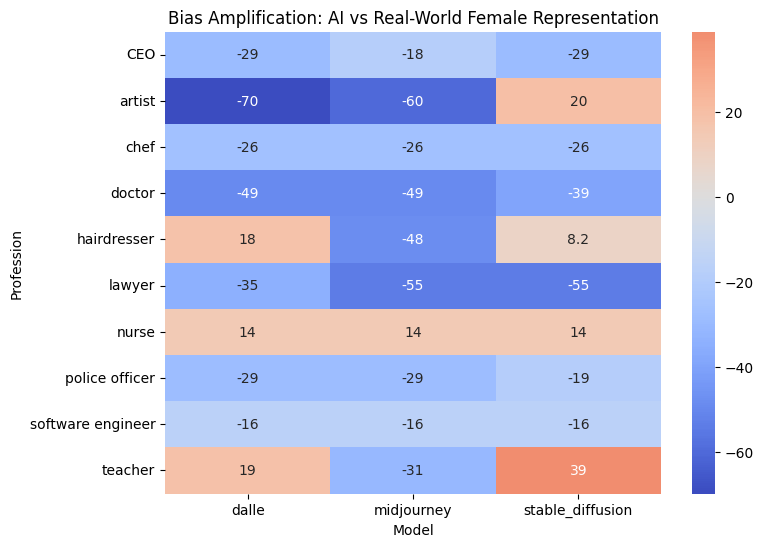

In [9]:
heatmap_data = result_df_models.pivot(
    index="profession",
    columns="model",
    values="difference"
)

plt.figure(figsize=(8,6))

sns.heatmap(
    heatmap_data,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Bias Amplification: AI vs Real-World Female Representation")
plt.ylabel("Profession")
plt.xlabel("Model")

plt.show()
